1. Importar librerías

In [1]:
from sklearn.datasets import fetch_20newsgroups

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

import matplotlib.pyplot as plt

import numpy as np

2. Descargar el dataset

In [2]:
categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.space',
    'talk.politics.misc'
]

news = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers','footers','quotes')
)

X_text = news.data
y_real = news.target

3. Convertir texto a números

In [3]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(X_text)

4. Reducir el tamaño para el dendrograma

In [4]:
X_small = X[:100].toarray()

5. Linkage Complete

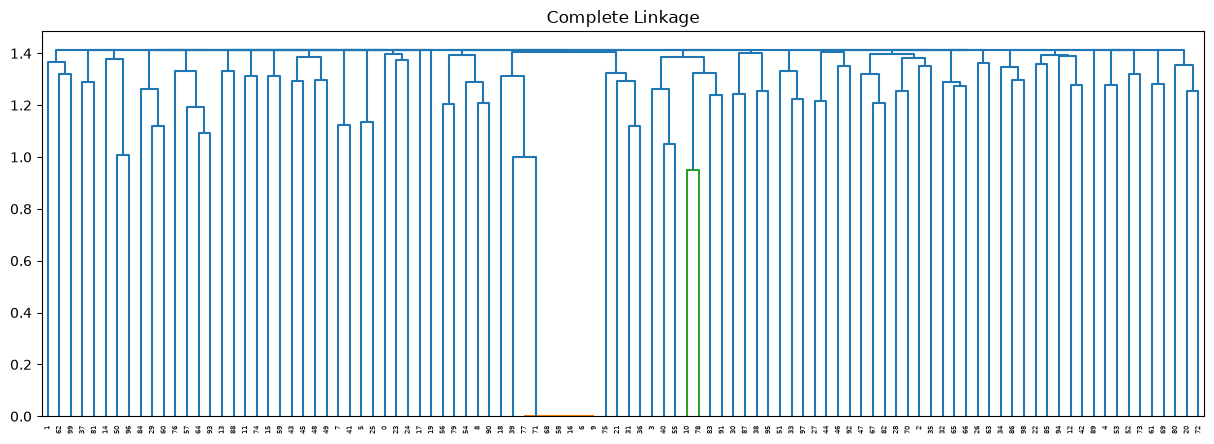

In [5]:
Z_complete = linkage(X_small, method='complete')

plt.figure(figsize=(15,5))
dendrogram(Z_complete)
plt.title("Complete Linkage")
plt.show()

6. Linkage Ward

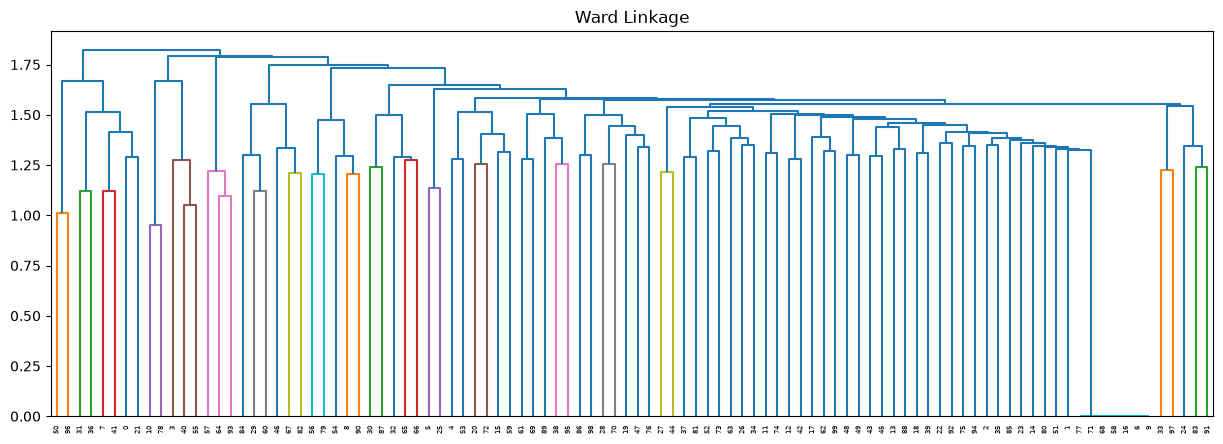

In [6]:
Z_ward = linkage(X_small, method='ward')

plt.figure(figsize=(15,5))
dendrogram(Z_ward)
plt.title("Ward Linkage")
plt.show()

7. Construcción de clusters

In [7]:
complete = AgglomerativeClustering(
    n_clusters=4,
    linkage='complete'
)

labels_complete = complete.fit_predict(X.toarray())

Ward

In [8]:
ward = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

labels_ward = ward.fit_predict(X.toarray())

8. Evaluación

In [9]:
score_complete = silhouette_score(
    X,
    labels_complete
)

score_ward = silhouette_score(
    X,
    labels_ward
)

print("Complete:", score_complete)
print("Ward:", score_ward)

Complete: 0.006400796008334435
Ward: 0.0110281117702106
